## Connection to MySql Database using the Python

In [1]:
import pymysql
import csv

In [ ]:
## Data Base details 
host = 
port = 
user = 
password = 
database = 

In [3]:
try:
    connection = pymysql.connect(
        host=host,
        port=port,
        user=user,
        password=password,
        database=database
    )

    query = "SELECT * FROM service_data"
    with connection.cursor() as cursor:
        cursor.execute(query)
        rows = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]

    with open("service_data.csv", mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(columns) 
        writer.writerows(rows)   

    print("Data downloaded successfully to 'service_data.csv'")

except pymysql.MySQLError as e:
    print("Error:", e)

finally:
    if 'connection' in locals() and connection.open:
        connection.close()

Data downloaded successfully to 'service_data.csv'


In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [5]:
data = pd.read_csv('service_data.csv')

In [6]:
data

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL
...,...,...,...,...,...,...,...
28477,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,SPROCKET RUBBER
28478,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,CLUTCH CABLE
28479,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,OIL FILTER
28480,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,DISC OIL


## Data Analysis

In [7]:
data.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


In [8]:
data.tail()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
28477,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,SPROCKET RUBBER
28478,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,CLUTCH CABLE
28479,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,OIL FILTER
28480,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,DISC OIL
28481,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,AIR FILTER


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28448 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [10]:
data.shape

(28482, 7)

In [11]:
data.columns

Index(['invoice_date', 'job_card_date', 'business_partner_name', 'vehicle_no',
       'vehicle_model', 'current_km_reading', 'invoice_line_text'],
      dtype='object')

In [12]:
data.duplicated().sum()

383

In [13]:
data['invoice_line_text'].unique()

array(['ENGINE OIL', 'POLISH', 'CONSUMABLES', 'COOLANT OIL',
       'CHAIN LUBRICATION', '4 WAY SWITCH', '3M OIL', 'GENERAL SERVICE',
       'OIL FILTER', 'INDICATOR', 'HEAD REST', 'VALVE GUIDE',
       'TIMMING CHAIN', 'FOOT REST', 'LOW BEAM BULB', 'VALVE GRAINDING',
       'DISC PAD', 'LOADING GEAR', 'PACKING KIT', 'TIMMING CHAIN PAD',
       'TENSIONER', 'CLUTCH BELL REST', 'CLUTCH ASSEMBLY', 'VALVE KIT',
       'SPARK PLUG', 'ONE WAY CLUTCH', 'BORE KIT', 'AIR FILTER',
       'HEAD RUBBER', 'CLUTCH CABLE', 'CRANK SHAFT', 'BRAKE ADJUSTMENT',
       'BRAKE SHOE', 'AIR FILTER CHECKUP', 'DRUM BOLT WASHER',
       'TANK CLEANING', 'FORK BEND', 'GEAR SHAFT', 'CLUTCH COVER GASKET',
       'INDICATOR BULB', 'GEAR LEVER', 'HANDLEBAR', 'CRASH GUARD',
       'FORK OIL SEAL', 'FORK OIL', 'SIDE SHIELD', 'VISIOR',
       'FORK CONE SET', 'HEAD LIGHT DOOM', 'TANK ASSEMBLY',
       'Clutch cable', 'DISC LEVER', 'CARBURETOR CLEANING', 'SEAT COVER',
       'BUZZER', 'TAIL LAMP BULB', 'DISC OIL', 'DIS

In [14]:
(data['invoice_line_text'].unique()).size

503

In [15]:
data['invoice_line_text'].value_counts()

ENGINE OIL              3802
CHAIN LUBRICATION       3441
GENERAL SERVICE         2142
AIR FILTER              1715
3M OIL                  1628
                        ... 
REGISTER EXPENSES          1
MAGNET COVER PACKING       1
CHAIN PAD                  1
DISK PLATE                 1
HELMET                     1
Name: invoice_line_text, Length: 502, dtype: int64

In [16]:
data['vehicle_model'].unique()

array(['BAJAJ AVENGER STREET 220', 'BAJAJ PULSAR NS 200', 'BAJAJ PLATINA',
       'BAJAJ V', 'BAJAJ PULSAR 150', 'BAJAJ PULSAR 220',
       'BAJAJ PULSAR 180', 'BAJAJ AVENGER STREET', 'BAJAJ CT 100',
       'BAJAJ DISCOVER', 'BAJAJ PULSAR LS135', 'BAJAJ DISCOVER 125',
       'BAJAJ V150', 'BAJAJ BOXER CT', 'BAJAJ PULSAR RS 200',
       'BAJAJ DISCOVER 150', 'BAJAJ PULSAR AS 200', 'BAJAJ XCD 125',
       'BAJAJ V125', 'BAJAJ WIND 125', 'BAJAJ DISCOVER 135',
       'BAJAJ PULSAR NS 160', 'BAJAJ CALIBER', 'BAJAJ XCD 135', 'WAVE',
       'BAJAJ AVENGER STREET 180', 'BAJAJ V15', 'BAJAJ DOMINAR 400 ABS'],
      dtype=object)

In [17]:
(data['vehicle_model'].unique()).size

28

In [18]:
data['vehicle_model'].value_counts()

BAJAJ PULSAR 150            8633
BAJAJ AVENGER STREET 220    4212
BAJAJ PULSAR 220            2655
BAJAJ PULSAR 180            2252
BAJAJ PULSAR NS 200         2204
BAJAJ CT 100                1432
BAJAJ DISCOVER 125          1346
BAJAJ AVENGER STREET        1112
BAJAJ PLATINA                844
BAJAJ V150                   686
BAJAJ DISCOVER               679
BAJAJ PULSAR LS135           520
BAJAJ PULSAR AS 200          421
BAJAJ PULSAR NS 160          364
BAJAJ PULSAR RS 200          322
BAJAJ DISCOVER 150           284
BAJAJ AVENGER STREET 180     122
BAJAJ DISCOVER 135           115
BAJAJ V125                    95
BAJAJ V                       54
BAJAJ CALIBER                 40
BAJAJ XCD 125                 27
BAJAJ V15                     23
BAJAJ XCD 135                 13
WAVE                          10
BAJAJ DOMINAR 400 ABS          7
BAJAJ WIND 125                 6
BAJAJ BOXER CT                 4
Name: vehicle_model, dtype: int64

In [19]:
data.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        34
dtype: int64

In [20]:
data.isnull().sum().any()

True

## EDA
Exploratory Data Analysis

Univarite analysis

- Categorical Variables: Plot the frequency distribution of each categorical variable.
- Numerical Variables: Display statistical summaries and plot histograms or boxplots to check for skewness or outliers.

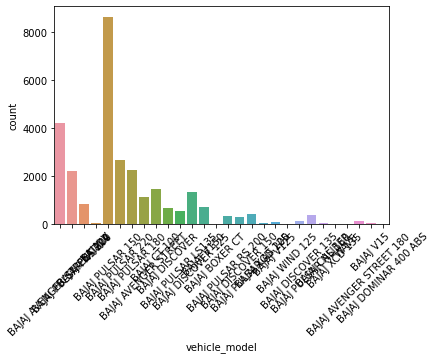

In [21]:
sns.countplot(data=data, x="vehicle_model")
plt.tick_params(axis='y', labelsize=10)  
plt.xticks(rotation=45)  
plt.show()

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'ENGINE OIL'),
  Text(1, 0, 'POLISH'),
  Text(2, 0, 'CONSUMABLES'),
  Text(3, 0, 'CHAIN LUBRICATION'),
  Text(4, 0, '3M OIL'),
  Text(5, 0, 'GENERAL SERVICE'),
  Text(6, 0, 'OIL FILTER'),
  Text(7, 0, 'AIR FILTER'),
  Text(8, 0, 'BRAKE SHOE'),
  Text(9, 0, 'DISC OIL')])

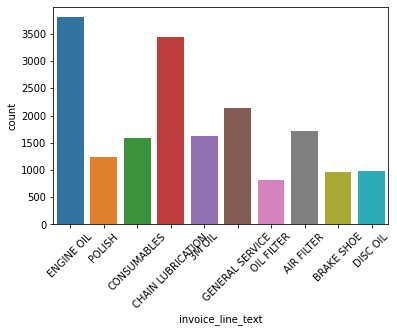

In [22]:
top_n = 10  
top_categories = data['invoice_line_text'].value_counts().nlargest(top_n).index
filtered_df = data[data['invoice_line_text'].isin(top_categories)]

sns.countplot(data=filtered_df, x='invoice_line_text')
plt.xticks(rotation=45)

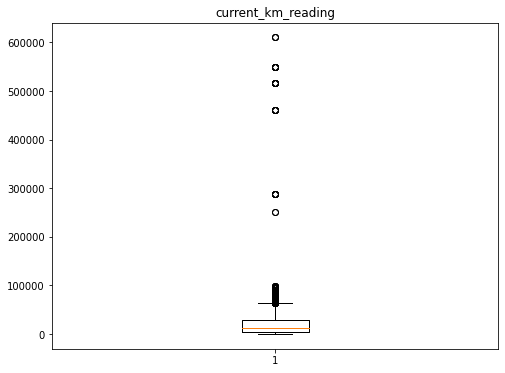

In [23]:
fig = plt.figure(figsize =(8, 6))
plt.boxplot(data.current_km_reading)
plt.title("current_km_reading")
plt.show()

## Multivariate Analysis

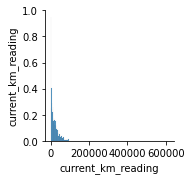

In [24]:
sns.pairplot(data)

## Complete Date Analysis Report
- Using the YData Profile

In [25]:
from ydata_profiling import ProfileReport

df = data
profile = ProfileReport(df, title="Profiling Report")

In [26]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

- using the sweetviz

In [27]:
import sweetviz as sv

In [28]:
data_univar_rpt = sv.analyze(data)

                                             |                                                                …

In [29]:
data_univar_rpt.show_html()

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Processing of Data
- Cleaning the data into proper format for the training of data

In [30]:
(data.isnull().sum()/data.shape[0]) * 100

invoice_date             0.000000
job_card_date            0.000000
business_partner_name    0.000000
vehicle_no               0.000000
vehicle_model            0.000000
current_km_reading       0.000000
invoice_line_text        0.119374
dtype: float64

In [31]:
data = data.dropna()

In [32]:
data.shape

(28448, 7)

## Handling outliers

In [33]:
data[data.current_km_reading > 100000].shape[0]

35

In [34]:
data = data[data.current_km_reading <= 100000].reset_index(drop=True)
data.shape

(28413, 7)

## dropping redundant columns ['invoice_date',  'business_partner_name', 'vehicle_no','current_km_reading']

In [35]:
data = data[['job_card_date', 'vehicle_model', 'invoice_line_text']]
data.shape

(28413, 3)

In [36]:
grouped_data = data.groupby(['vehicle_model'])['invoice_line_text'].count().reset_index()
grouped_data.rename(columns={'invoice_line_text': 'count'}, inplace=True)
grouped_data = grouped_data.sort_values(by='count', ascending=False)
grouped_data

,vehicle_model,count
12,BAJAJ PULSAR 150,8599
2,BAJAJ AVENGER STREET 220,4212
14,BAJAJ PULSAR 220,2654
13,BAJAJ PULSAR 180,2251
18,BAJAJ PULSAR NS 200,2203
5,BAJAJ CT 100,1432
7,BAJAJ DISCOVER 125,1345
0,BAJAJ AVENGER STREET,1111
11,BAJAJ PLATINA,843
23,BAJAJ V150,685


In [37]:
grouped_data = data.groupby(['invoice_line_text'])['vehicle_model'].count().reset_index()
grouped_data.rename(columns={'vehicle_model': 'count'}, inplace=True)
grouped_data = grouped_data.sort_values(by='count', ascending=False)
grouped_data

,invoice_line_text,count
148,ENGINE OIL,3799
76,CHAIN LUBRICATION,3437
209,GENERAL SERVICE,2136
10,AIR FILTER,1713
2,3M OIL,1628
...,...,...
369,RIM,1
370,RIM TUBLESS NECK,1
205,GEAR LEVER WELDING,1
203,GEAR LEVER OIL SEAL,1


In [38]:
data['invoice_line_text'].nunique()

502

In [39]:
for item in data.invoice_line_text.unique():
    print(f"'{item}',")

'ENGINE OIL',
'POLISH',
'CONSUMABLES',
'COOLANT OIL',
'CHAIN LUBRICATION',
'4 WAY SWITCH',
'3M OIL',
'GENERAL SERVICE',
'OIL FILTER',
'INDICATOR',
'HEAD REST',
'VALVE GUIDE',
'TIMMING CHAIN',
'FOOT REST',
'LOW BEAM BULB',
'VALVE GRAINDING',
'DISC PAD',
'LOADING GEAR',
'PACKING KIT',
'TIMMING CHAIN PAD',
'TENSIONER',
'CLUTCH BELL REST',
'CLUTCH ASSEMBLY',
'VALVE KIT',
'SPARK PLUG',
'ONE WAY CLUTCH',
'BORE KIT',
'AIR FILTER',
'HEAD RUBBER',
'CLUTCH CABLE',
'CRANK SHAFT',
'BRAKE ADJUSTMENT',
'BRAKE SHOE',
'AIR FILTER CHECKUP',
'DRUM BOLT WASHER',
'TANK CLEANING',
'FORK BEND',
'GEAR SHAFT',
'CLUTCH COVER GASKET',
'INDICATOR BULB',
'GEAR LEVER',
'HANDLEBAR',
'CRASH GUARD',
'FORK OIL SEAL',
'FORK OIL',
'SIDE SHIELD',
'VISIOR',
'FORK CONE SET',
'HEAD LIGHT DOOM',
'TANK ASSEMBLY',
'Clutch cable',
'DISC LEVER',
'CARBURETOR CLEANING',
'SEAT COVER',
'BUZZER',
'TAIL LAMP BULB',
'DISC OIL',
'DISC OVERHUAL',
'MASTER ASSEMBLY',
'CHAIN COVER RUBBER',
'ENGINE GUARD',
'CLUTCH CAM ',
'DOOM',
'WHEEL RUBBE

## Data Preprocessing

In [40]:
data['invoice_line_text'] = data['invoice_line_text'].str.replace('BULB ', 'BULB')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('OVERHUAL', 'OVERHAUL')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('WIELDING', 'WELDING')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('ENGINE OIL TOPUP', 'ENGINE OIL')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('ASSEBLY', 'ASSEMBLY')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('GRIP HANDLE', 'HANDLE GRIPPER')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('HANDLEBAR', 'HANDLE BAR')
data['invoice_line_text'] = data['invoice_line_text'].str.replace('NUMBER PLATE WITH STICKERS', 'NUMBER PLATE')

In [41]:
service_related_tokens = [
'OVERHAUL', 
'WELDING',
'SERVICE', 
'WORK',
'PUNCHER',
'REBORE',
'DENT',
'RC CARD',
'TAX',
'ENGINE WORK',
'CHECK',
'LABOUR',
'CHARGE',
'FEES',
'PAYMENT',
'STICKERS'
'ADJUSTMENT',
'REGISTOR',
'INSURANCE',
'ADJUSTMENT',
'REMOVAL', 
'THREADING', 
'CLEANING',
]
services = []
for item in data.invoice_line_text.unique():
    try:
        if sum([item.find(token)!= -1 for token in service_related_tokens]) > 0:
            services.append(item)
    except:
        print(item)
        
need_to_be_removed_in_services = [
'PETROL',
'VALVE GRAINDING',
'CHAIN LUBRICATION',
'ENGINE RE CONDITION',
'HEAD LIGHT WIRING',
'EX SHOW ROOM'
]
services.extend(need_to_be_removed_in_services)

In [42]:
len(services)

67

In [43]:
for item in data.invoice_line_text.unique():
    if item not in services:
        print(item)

ENGINE OIL
POLISH
CONSUMABLES
COOLANT OIL
4 WAY SWITCH
3M OIL
OIL FILTER
INDICATOR
HEAD REST
VALVE GUIDE
TIMMING CHAIN
FOOT REST
LOW BEAM BULB
DISC PAD
LOADING GEAR
PACKING KIT
TIMMING CHAIN PAD
TENSIONER
CLUTCH BELL REST
CLUTCH ASSEMBLY
VALVE KIT
SPARK PLUG
ONE WAY CLUTCH
BORE KIT
AIR FILTER
HEAD RUBBER
CLUTCH CABLE
CRANK SHAFT
BRAKE SHOE
DRUM BOLT WASHER
FORK BEND
GEAR SHAFT
CLUTCH COVER GASKET
INDICATOR BULB
GEAR LEVER
HANDLE BAR
CRASH GUARD
FORK OIL SEAL
FORK OIL
SIDE SHIELD
VISIOR
FORK CONE SET
HEAD LIGHT DOOM
TANK ASSEMBLY
Clutch cable
DISC LEVER
SEAT COVER
BUZZER
TAIL LAMP BULB
DISC OIL
MASTER ASSEMBLY
CHAIN COVER RUBBER
ENGINE GUARD
CLUTCH CAM 
DOOM
WHEEL RUBBER
bore kit
ENGINE BEARING
CRANK RESET
CARBURETOR DIAPHRAGM RUBBER
CLUTCH LEVER
DRUM BOLT
LOCK SET
RIGHT SHIELD CAP
SWITCH
SHOCK ABSORBER
STEP HOLDER
ACCELATOR CABLE
JALL SCREW
TANK COVER
HANDLE LOCK
GRIPPER
PARKING BULB
WIND SHIELD
SPEEDOMETER CAP
HEAD LIGHT STAY
CONE SET
DOOM SCREW KIT
DISK PAD
HEAD LIGHT BULB
CALIPER AS

In [44]:
data = data[~data.invoice_line_text.isin(services)]
data = data.reset_index(drop=True)
data.shape

(21298, 3)

In [45]:
data.head()

,job_card_date,vehicle_model,invoice_line_text
0,30-05-17,BAJAJ AVENGER STREET 220,ENGINE OIL
1,31-05-17,BAJAJ PULSAR NS 200,ENGINE OIL
2,31-05-17,BAJAJ PULSAR NS 200,POLISH
3,31-05-17,BAJAJ PULSAR NS 200,CONSUMABLES
4,31-05-17,BAJAJ PULSAR NS 200,COOLANT OIL


In [46]:
data.rename(columns={"job_card_date":"date", "invoice_line_text":"spare_part"}, inplace=True)

In [47]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%y')

In [48]:
data.head()

,date,vehicle_model,spare_part
0,2017-05-30,BAJAJ AVENGER STREET 220,ENGINE OIL
1,2017-05-31,BAJAJ PULSAR NS 200,ENGINE OIL
2,2017-05-31,BAJAJ PULSAR NS 200,POLISH
3,2017-05-31,BAJAJ PULSAR NS 200,CONSUMABLES
4,2017-05-31,BAJAJ PULSAR NS 200,COOLANT OIL


## Advanced EDA

In [49]:
value_counts = data['spare_part'].value_counts()
print(value_counts)

ENGINE OIL              3804
AIR FILTER              1713
3M OIL                  1628
CONSUMABLES             1595
POLISH                  1245
                        ... 
REGISTER EXPENSES          1
SWITCH                     1
MAGNET COVER PACKING       1
CLUTCH OUTLET PIPE         1
HELMET                     1
Name: spare_part, Length: 431, dtype: int64


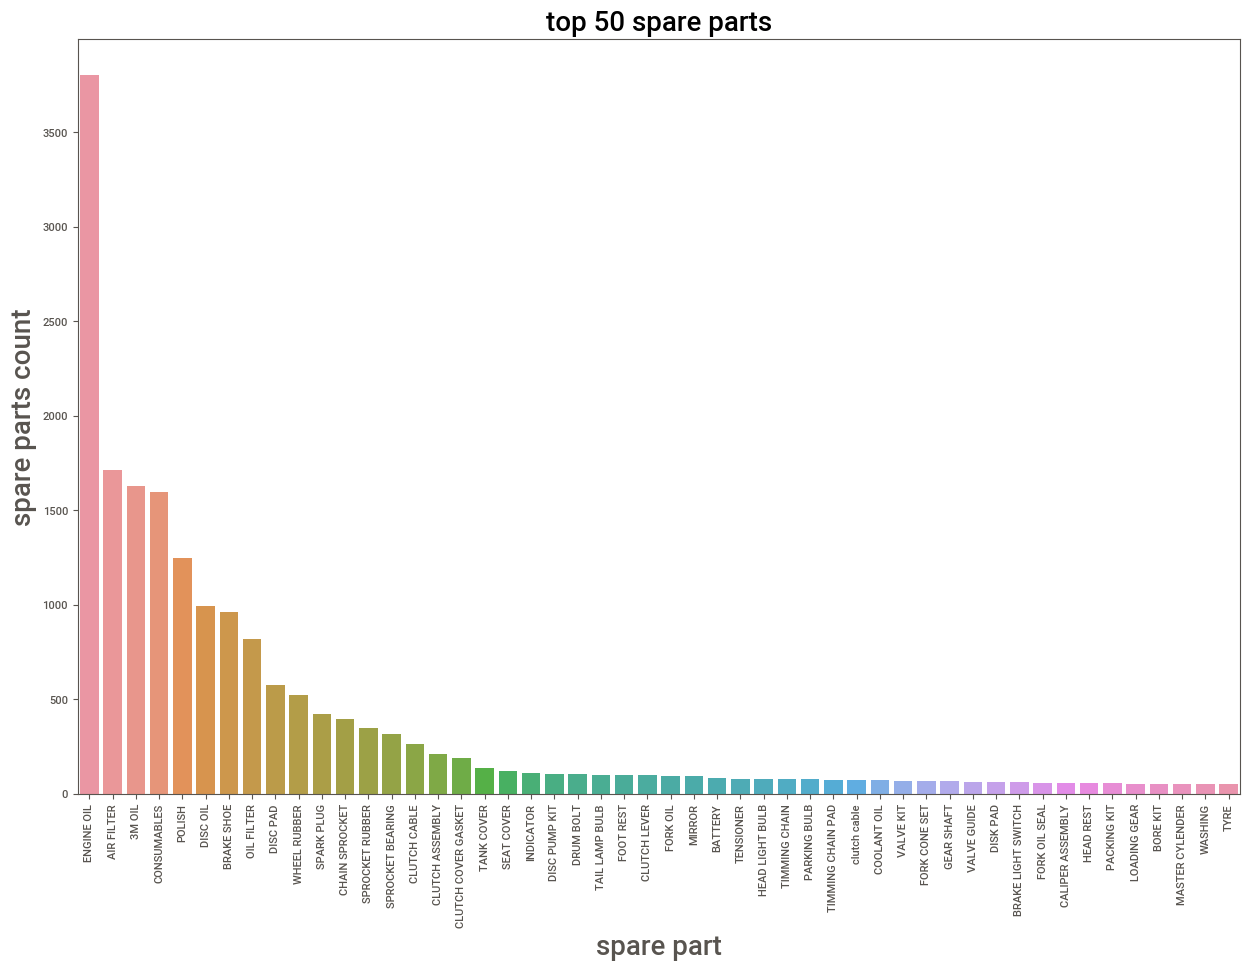

In [50]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.countplot(data=data, x='spare_part',
              order=data['spare_part'].value_counts().index[:50],
              ax=ax)

ax.set_title('top 50 spare parts', fontsize=20)
ax.set_ylabel('spare parts count', fontsize=20)
ax.set_xlabel('spare part', fontsize=20)
ax.tick_params(axis='x', rotation=90)
plt.show()

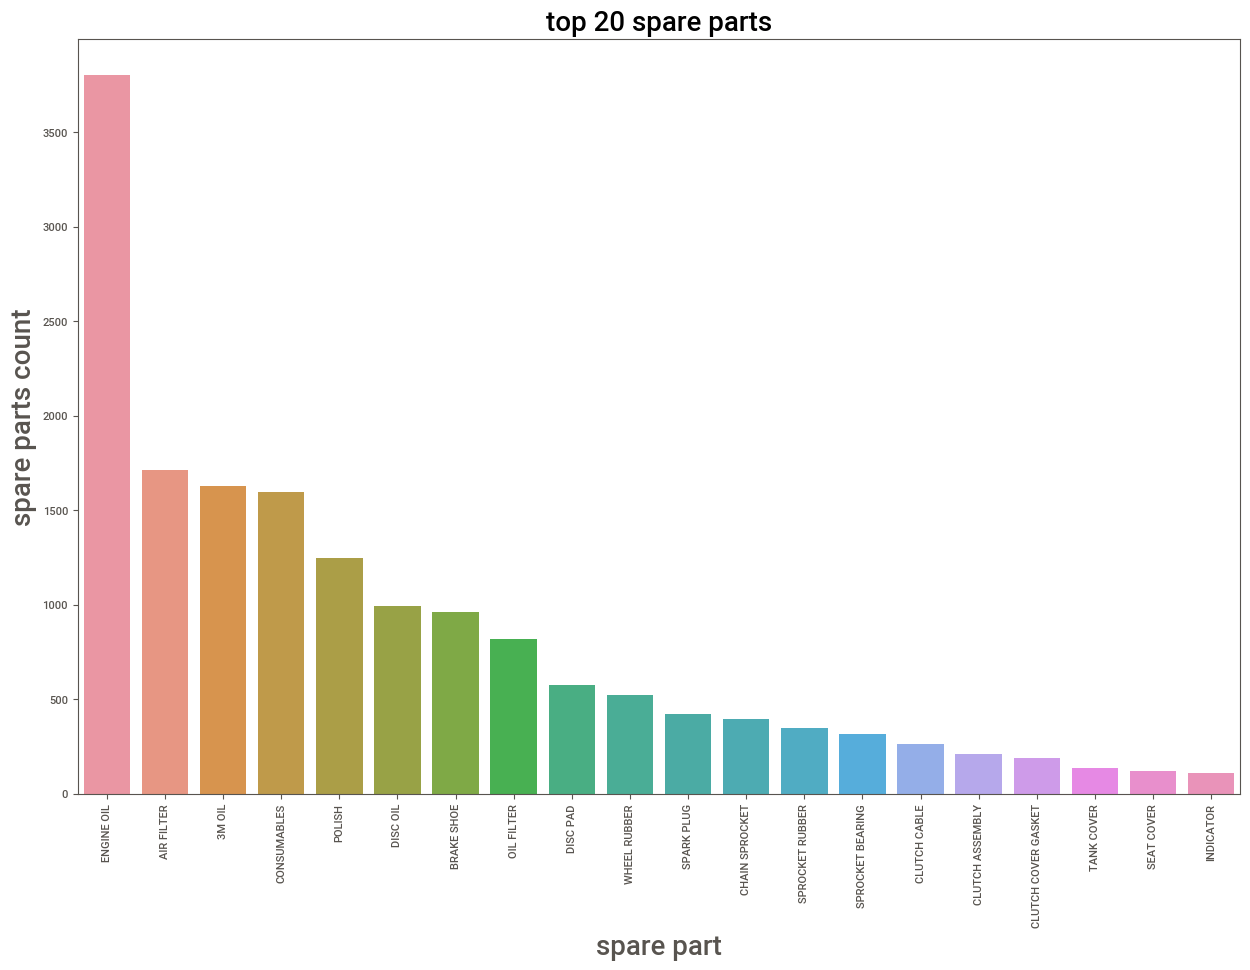

In [51]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.countplot(data=data, x='spare_part',
              order=data['spare_part'].value_counts().index[:20],
              ax=ax)

ax.set_title('top 20 spare parts', fontsize=20)
ax.set_ylabel('spare parts count', fontsize=20)
ax.set_xlabel('spare part', fontsize=20)
ax.tick_params(axis='x', rotation=90)
plt.show()

In [52]:
vm_grouped_data = data.groupby(['vehicle_model'])['spare_part'].count().reset_index()
vm_grouped_data.rename(columns={'spare_part': 'count'}, inplace=True)
vm_grouped_data = vm_grouped_data.sort_values(by='count', ascending=False)
vm_grouped_data

,vehicle_model,count
12,BAJAJ PULSAR 150,6480
2,BAJAJ AVENGER STREET 220,3058
14,BAJAJ PULSAR 220,1984
18,BAJAJ PULSAR NS 200,1705
13,BAJAJ PULSAR 180,1703
5,BAJAJ CT 100,1119
7,BAJAJ DISCOVER 125,1027
0,BAJAJ AVENGER STREET,767
11,BAJAJ PLATINA,661
23,BAJAJ V150,523


In [53]:
sp_grouped_data = data.groupby(['spare_part'])['vehicle_model'].count().reset_index()
sp_grouped_data.rename(columns={'vehicle_model': 'count'}, inplace=True)
sp_grouped_data = sp_grouped_data.sort_values(by='count', ascending=False)
sp_grouped_data

,spare_part,count
127,ENGINE OIL,3804
9,AIR FILTER,1713
2,3M OIL,1628
90,CONSUMABLES,1595
298,POLISH,1245
...,...,...
232,LEVER BOLT,1
233,LEVER RUBBER,1
236,LIGHTING COIL,1
243,MAGNET ASSEMBLY,1


In [54]:
data.date.nunique()

553

In [55]:
sp_grouped_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 431 entries, 127 to 430
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   spare_part  431 non-null    object
 1   count       431 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 10.1+ KB


In [56]:
sp_grouped_data.shape[0]

431

In [57]:
sp_grouped_data[sp_grouped_data['count']>1].shape[0]

288

In [58]:
sp_grouped_data[sp_grouped_data['count']>10].shape[0]

128

In [59]:
sp_grouped_data[sp_grouped_data['count']>=100].shape[0]

23

In [60]:
data_indexed = data.set_index('date')
data_indexed.head()

,vehicle_model,spare_part
date,,
2017-05-30,BAJAJ AVENGER STREET 220,ENGINE OIL
2017-05-31,BAJAJ PULSAR NS 200,ENGINE OIL
2017-05-31,BAJAJ PULSAR NS 200,POLISH
2017-05-31,BAJAJ PULSAR NS 200,CONSUMABLES
2017-05-31,BAJAJ PULSAR NS 200,COOLANT OIL


In [61]:
weekly_data_indexed = data_indexed[['spare_part']].resample('W').count()
weekly_data_indexed.shape

(84, 1)

In [62]:
weekly_data_indexed.head()

,spare_part
date,
2017-06-04,116
2017-06-11,237
2017-06-18,252
2017-06-25,219
2017-07-02,197


<Figure size 1500x1000 with 0 Axes>

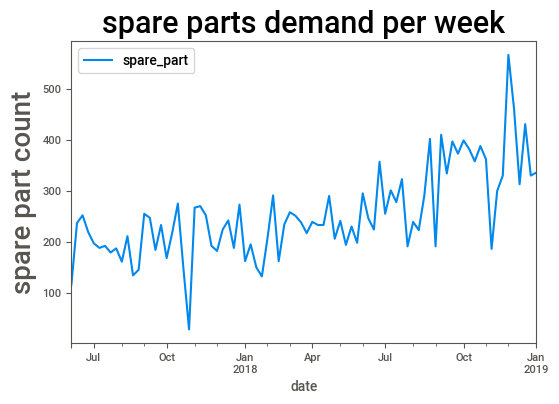

In [63]:
plt.figure(figsize=(15, 10))
weekly_data_indexed.plot()
plt.title('spare parts demand per week', fontsize=22)
plt.ylabel('spare part count', fontsize=20)
plt.show()

## Time Series Analysis
Analyzing the spare parts demand over time.

I will be exploring following statistical techniques over the above data to understand overall pattern and behaviour of the inventory data.

- Time Downsampling
- Moving Average with rolling window
- Cummulative mean with expanding window
- Exponential Weighted Moving Average
- Time series stationarity

## Time Downsampling
In above steps, I resampled the data on weekly level. Let's see the demand of spare parts on monthly level.

In [64]:
monthly_data_indexed = weekly_data_indexed.resample('M').sum()
monthly_data_indexed.head()

,spare_part
date,
2017-06-30,824
2017-07-31,943
2017-08-31,651
2017-09-30,919
2017-10-31,836


### plot the weekly demand and monthly demand on same view

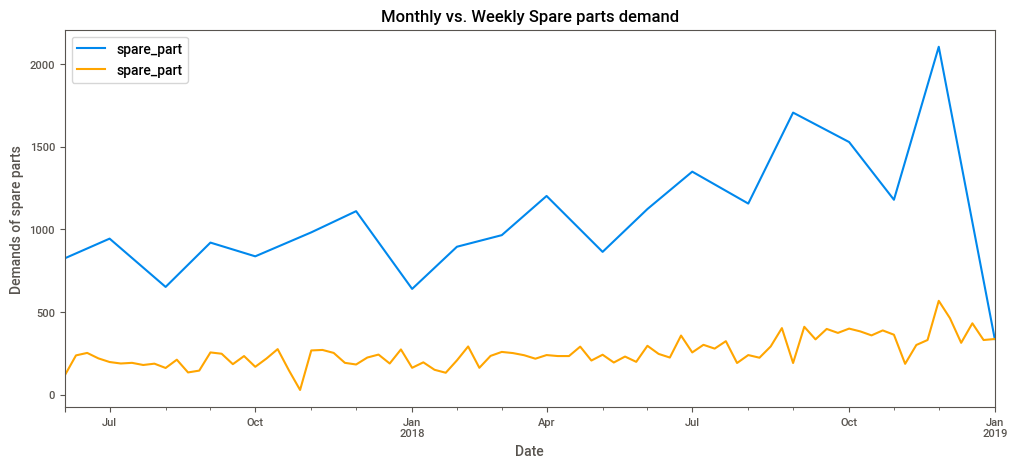

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_data_indexed.plot(ax=ax, label='Monthly Demand')
weekly_data_indexed.plot(ax=ax, label='Weekly Demand', color='orange')
ax.set_xlabel('Date')
ax.set_ylabel('Demands of spare parts')
ax.set_title('Monthly vs. Weekly Spare parts demand')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

## Moving Average rolling window
Let's apply some smoothing techniques to understand overall behaviour the data.

In [66]:
weekly_data_indexed.columns

Index(['spare_part'], dtype='object')

In [67]:
window = 4
weekly_data_indexed['4W_MA'] = weekly_data_indexed['spare_part'].rolling(window).mean()

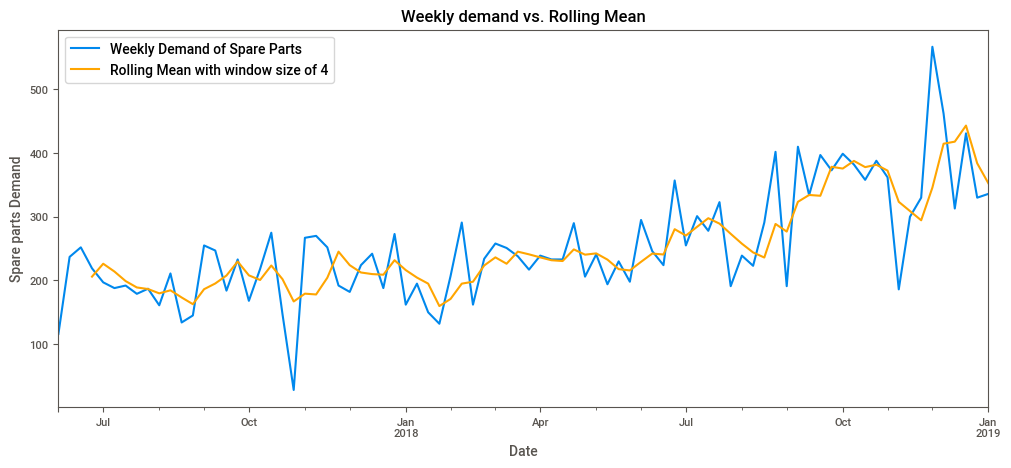

In [68]:
fig, ax = plt.subplots(figsize=(12, 5))
# weekly demand
weekly_data_indexed['spare_part'].plot(ax=ax, label='Weekly Demand of Spare Parts')

# MA with window size 4
weekly_data_indexed['4W_MA'].plot(ax=ax, label='Rolling Mean with window size of 4', color='orange')

ax.set_xlabel('Date')
ax.set_ylabel('Spare parts Demand')
ax.set_title('Weekly demand vs. Rolling Mean')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')
plt.show()

## Cumulative mean with expanding window
This can be helpful for understanding trends and pattern in the data over time.

In [69]:
weekly_data_indexed['4W_CM'] = weekly_data_indexed['spare_part'].expanding(min_periods=4).mean()
weekly_data_indexed.head(10)

,spare_part,4W_MA,4W_CM
date,,,
2017-06-04,116,NaN,NaN
2017-06-11,237,NaN,NaN
2017-06-18,252,NaN,NaN
2017-06-25,219,206.00,206.000000
2017-07-02,197,226.25,204.200000
2017-07-09,188,214.00,201.500000
2017-07-16,192,199.00,200.142857
2017-07-23,179,189.00,197.500000
2017-07-30,187,186.50,196.333333


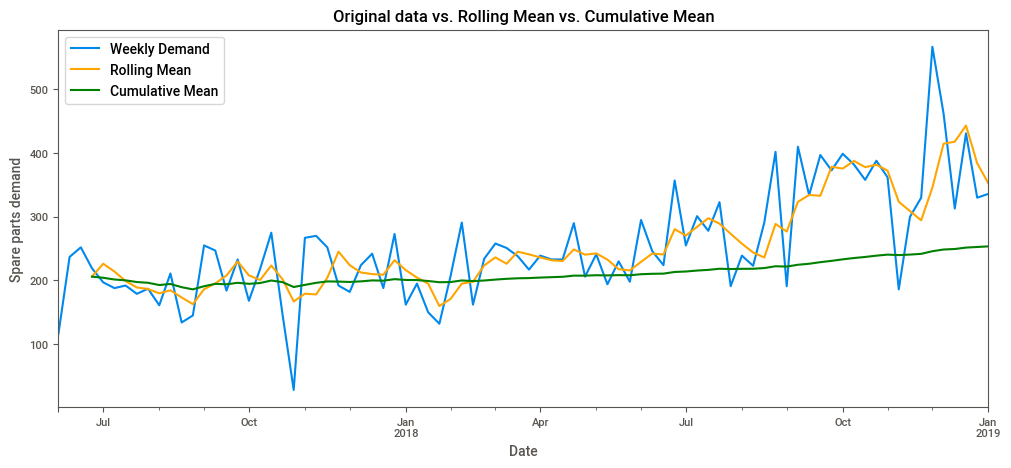

In [70]:
fig, ax = plt.subplots(figsize=(12, 5))
weekly_data_indexed['spare_part'].plot(ax=ax, label='Weekly Demand')

# Plot the rolling mean
weekly_data_indexed['4W_MA'].plot(ax=ax, label='Rolling Mean', color='orange')

# Plot the  cumulative mean
weekly_data_indexed['4W_CM'].plot(ax=ax, label='Cumulative Mean', color='green')

ax.set_xlabel('Date')
ax.set_ylabel('Spare parts demand')
ax.set_title('Original data vs. Rolling Mean vs. Cumulative Mean')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')
plt.show()

## Time Series Stationarity
A time series is stationary if the mean and variance are fixed between two equidistance points.

Most the models like ARIMA and it's submodels need the stationary time series data.

Let's check if our data has some trend/seasonality or it is stationary. For stationarity check we can conduct augmented dickey fuller test.

In [71]:
from statsmodels.tsa.stattools import adfuller

In [72]:
print('Augmented Dickey-Fuller Test on Inventory Sales Data')
dftest = adfuller(weekly_data_indexed['spare_part'], autolag='AIC')

#covert into dataframe
dfout = pd.Series(dftest[0:4], index=['ADF test statistic','p-value','# lags used','# observations'])


for key,val in dftest[4].items():
    dfout[f'critical value ({key})']=val
print(dfout)

Augmented Dickey-Fuller Test on Inventory Sales Data
ADF test statistic      -1.173080
p-value                  0.685068
# lags used              4.000000
# observations          79.000000
critical value (1%)     -3.515977
critical value (5%)     -2.898886
critical value (10%)    -2.586694
dtype: float64


## Differencing
Let's trying to make the series stationary

We can use first order of differencing to make it stationary.

In [73]:
from statsmodels.tsa.statespace.tools import diff

weekly_data_indexed['spare_part_diff'] = diff(weekly_data_indexed['spare_part'], k_diff=1)

weekly_data_indexed.head(5)

,spare_part,4W_MA,4W_CM,spare_part_diff
date,,,,
2017-06-04,116,NaN,NaN,NaN
2017-06-11,237,NaN,NaN,121.0
2017-06-18,252,NaN,NaN,15.0
2017-06-25,219,206.00,206.0,-33.0
2017-07-02,197,226.25,204.2,-22.0


In [74]:
weekly_data_indexed = weekly_data_indexed[['spare_part', 'spare_part_diff']]

In [75]:
weekly_data_indexed.head()

,spare_part,spare_part_diff
date,,
2017-06-04,116,NaN
2017-06-11,237,121.0
2017-06-18,252,15.0
2017-06-25,219,-33.0
2017-07-02,197,-22.0


<AxesSubplot: title={'center': 'First order differencing'}, xlabel='date'>

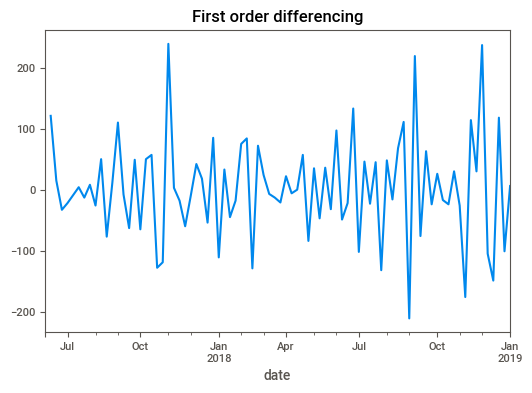

In [76]:
weekly_data_indexed['spare_part_diff'].plot(title="First order differencing")

In [77]:
#drop first NaN entry
weekly_data_indexed = weekly_data_indexed.dropna()

In [78]:
print('Augmented Dickey-Fuller Test on Airline Data')
dftest = adfuller(weekly_data_indexed['spare_part_diff'], autolag='AIC')

#covert into dataframe
dfout = pd.Series(dftest[0:4], index=['ADF test statistic','p-value','# lags used','# observations'])


for key,val in dftest[4].items():
    dfout[f'critical value ({key})']=val
print(dfout)

Augmented Dickey-Fuller Test on Airline Data
ADF test statistic     -7.704757e+00
p-value                 1.310568e-11
# lags used             3.000000e+00
# observations          7.900000e+01
critical value (1%)    -3.515977e+00
critical value (5%)    -2.898886e+00
critical value (10%)   -2.586694e+00
dtype: float64


## Time Series Forecasting
Since we are done with Analysis of our data. We also checked for stationarity and then we introduced first order differencing to make the time series stationary.

We can now move ahead for modeling and forecasting for future dates.

We have a lot of options while doing model selection like we can use Auto Regression(AR), Autoregressive Moving Average(ARMA) or Autoregressive Integreted Moving Average(ARIMA).

Right now, I’m using... Triple Exponential Smoothing for setting the base line and the SARIMA model to get better result.

In [79]:
X = weekly_data_indexed

# Calculate the split point based on an 80:20 ratio
split_point = 16

# Split the data into train and test sets
train_data = X[:-split_point]
test_data = X[-split_point:]

# print the lengths of the train and test sets
print('Train data length:', len(train_data))
print('Test data length:', len(test_data))

Train data length: 67
Test data length: 16


In [80]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

fitted_model = ExponentialSmoothing(train_data['spare_part'], trend='mul', seasonal='add', seasonal_periods=26).fit()

In [81]:
test_predictions = fitted_model.forecast(len(test_data))

In [82]:
test_predictions

2018-09-23    334.649571
2018-09-30    308.325520
2018-10-07    339.967663
2018-10-14    380.239017
2018-10-21    329.703235
2018-10-28    226.118324
2018-11-04    387.815126
2018-11-11    377.423907
2018-11-18    387.389823
2018-11-25    343.951881
2018-12-02    380.131964
2018-12-09    393.855877
2018-12-16    403.830371
2018-12-23    423.726944
2018-12-30    424.457914
2019-01-06    395.028055
Freq: W-SUN, dtype: float64

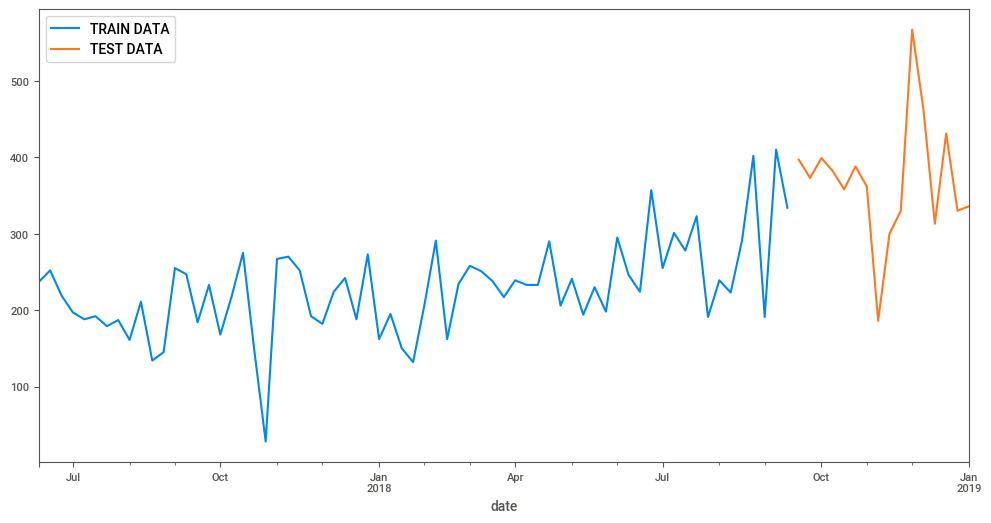

In [83]:
train_data['spare_part'].plot(legend=True, label='TRAIN DATA')
test_data['spare_part'].plot(legend=True, label='TEST DATA', figsize=(12, 6)).autoscale(axis='x', tight=True)

<AxesSubplot: xlabel='date'>

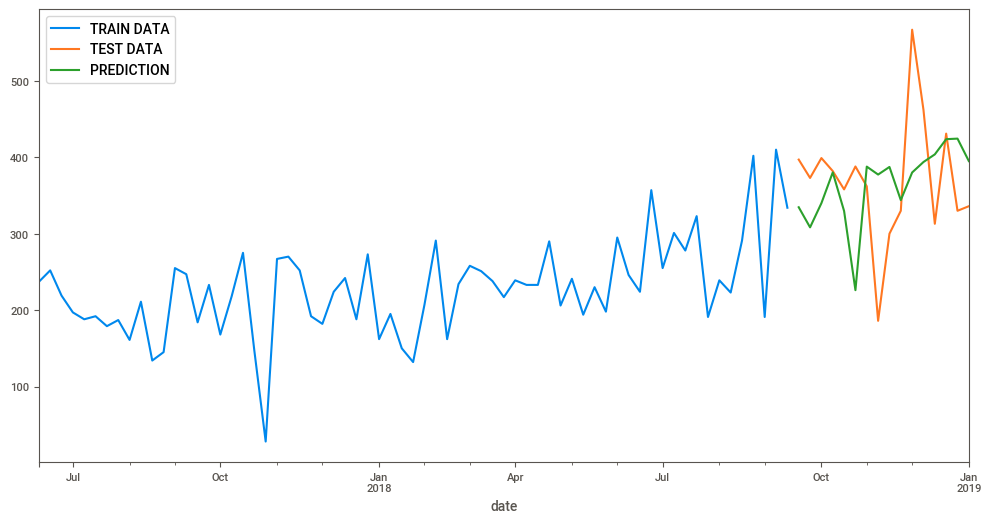

In [84]:
train_data['spare_part'].plot(legend=True, label='TRAIN DATA')
test_data['spare_part'].plot(legend=True, label='TEST DATA', figsize=(12, 6)).autoscale(axis='x', tight=True)
test_predictions.plot(legend=True, label='PREDICTION')

### Evaluation Metrics

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [86]:
mae_error = mean_absolute_error(test_data['spare_part'], test_predictions)
print(f"Mean absolute error of the above model is {mae_error}")

Mean absolute error of the above model is 75.19868512986459


In [87]:
mse_error = mean_squared_error(test_data['spare_part'], test_predictions)
print(f"Mean squared error of the above model is {mse_error}")

Mean squared error of the above model is 8998.673882958548


## Seasonal Autoregressive Integreted Moving Average(SARIMA)

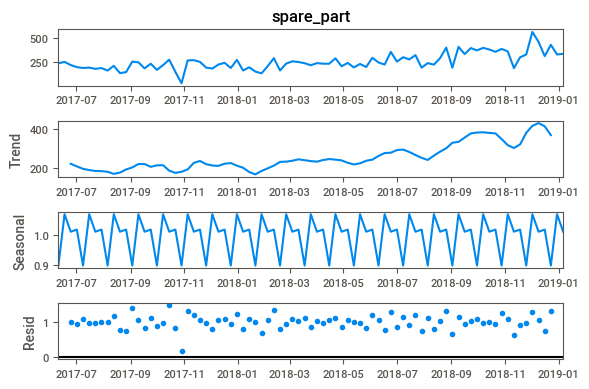

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(weekly_data_indexed['spare_part'], model='mul', period=4)
result.plot();

In [89]:
max(result.seasonal), min(result.seasonal)

(1.0707335507260987, 0.898151724320523)

In [92]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose     
from pmdarima import auto_arima   

In [93]:
auto_arima(train_data['spare_part'], seasonal=True,m=12).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   67
Model:             SARIMAX(5, 1, 1)x(1, 0, [], 12)   Log Likelihood                -357.921
Date:                             Tue, 21 Jan 2025   AIC                            733.843
Time:                                     18:57:16   BIC                            753.550
Sample:                                 06-11-2017   HQIC                           741.630
                                      - 09-16-2018                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.3680      1.158      1.181      0.237      -0.902       3.638
ar.L1         -0.0585      0.165     -0.356      0.722      -0.381       0.264
ar.L2         -0.0975      0.173     -0.563      0.574      -0.437       0.242
ar.L3          0.0503      0.174      0.289      0.772      -0.290       0.391
ar.L4         -0.0504      0.179     -0.282      0.778      -0.401       0.300
ar.L5          0.0535      0.179      0.298      0.765      -0.298       0.405
ma.L1         -0.9879      0.307     -3.222      0.001      -1.589      -0.387
ar.S.L12       0.2165      0.165      1.312      0.190      -0.107       0.540
sigma2      2848.1489    740.127      3.848      0.000    1397.527    4298.771
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 3.78
Prob(Q):                              0.87   Prob(JB):                         0.15
Heteroskedasticity (H):               1.22   Skew:                             0.05
Prob(H) (two-sided):                  0.64   Kurtosis:                         4.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [94]:
from statsmodels.tsa.arima_model import ARIMA,ARIMAResults

In [95]:
model = SARIMAX(train_data['spare_part'],order=(5,1,1), seasonal_order=(1, 0, 0, 12))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                          spare_part   No. Observations:                   67
Model:             SARIMAX(5, 1, 1)x(1, 0, [], 12)   Log Likelihood                -359.625
Date:                             Tue, 21 Jan 2025   AIC                            735.250
Time:                                     19:00:20   BIC                            752.767
Sample:                                 06-11-2017   HQIC                           742.172
                                      - 09-16-2018                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1307      0.261     -0.502      0.616      -0.641       0.380
ar.L2         -0.1479      0.241     -0.613      0.540      -0.621       0.325
ar.L3          0.0067      0.247      0.027      0.978      -0.477       0.491
ar.L4         -0.0720      0.212     -0.340      0.734      -0.487       0.343
ar.L5          0.0415      0.223      0.186      0.853      -0.396       0.479
ma.L1         -0.8333      0.214     -3.902      0.000      -1.252      -0.415
ar.S.L12       0.2224      0.179      1.240      0.215      -0.129       0.574
sigma2      3060.7657    521.074      5.874      0.000    2039.480    4082.051
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.93
Prob(Q):                              0.86   Prob(JB):                         0.63
Heteroskedasticity (H):               1.33   Skew:                            -0.03
Prob(H) (two-sided):                  0.51   Kurtosis:                         3.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [96]:
# Obtain predicted values
start=len(train_data)
end=len(train_data)+len(test_data)-1
predictions = results.predict(start=start, end=end, dynamic=False, typ='levels')

In [97]:
# Compare predictions to expected values
for i in range(len(predictions)):
    print(f"predicted={predictions[i]:<11.10}, expected={test_data['spare_part'][i]}")

predicted=266.3884672, expected=397
predicted=317.7097213, expected=373
predicted=288.7464434, expected=399
predicted=312.3835184, expected=382
predicted=283.8946755, expected=358
predicted=287.4628657, expected=388
predicted=288.2153937, expected=362
predicted=301.8649572, expected=186
predicted=326.566275 , expected=300
predicted=280.4248044, expected=330
predicted=328.4191542, expected=567
predicted=311.7755701, expected=462
predicted=296.7515573, expected=313
predicted=308.0652506, expected=431
predicted=301.720194 , expected=330
predicted=306.9318002, expected=336


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Weekly Demand')]

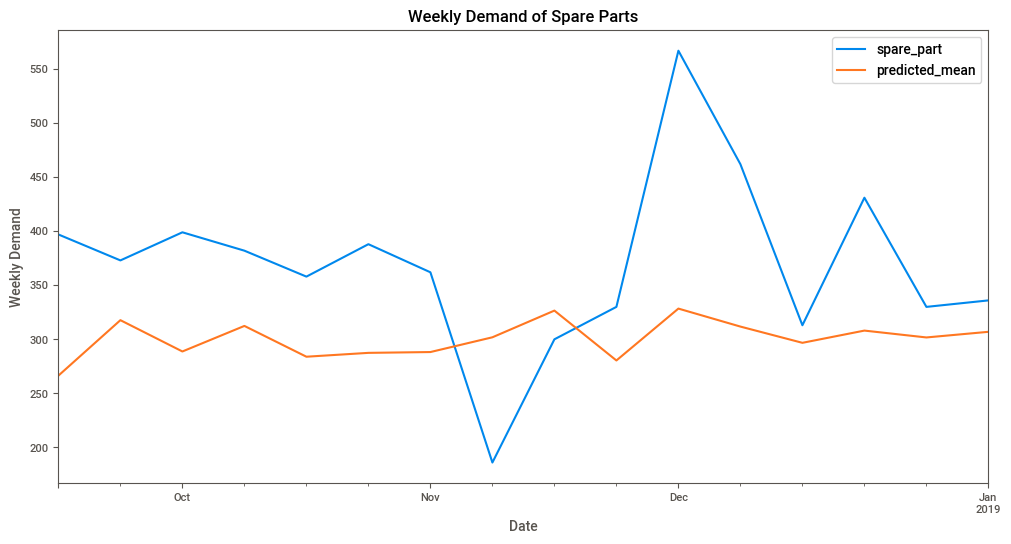

In [98]:
title = 'Weekly Demand of Spare Parts'
ylabel='Weekly Demand'
xlabel='Date'

ax = test_data['spare_part'].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [99]:
from sklearn.metrics import mean_squared_error


error = mean_squared_error(test_data['spare_part'], predictions)
print(f'SARIMA(2,0,1,12) MSE Error: {error:11.10}')

SARIMA(2,0,1,12) MSE Error: 10703.76238


## Forecast for next 16 weeks

In [100]:
model = SARIMAX(weekly_data_indexed['spare_part'],order=(5,1,1), seasonal_order=(1, 0, 0, 12))

results = model.fit()
fcast = results.predict(len(weekly_data_indexed),len(weekly_data_indexed)+15,typ='levels').rename('SARIMA(5,1,1)(1,0,0,12) Forecast')

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Weekly Demand')]

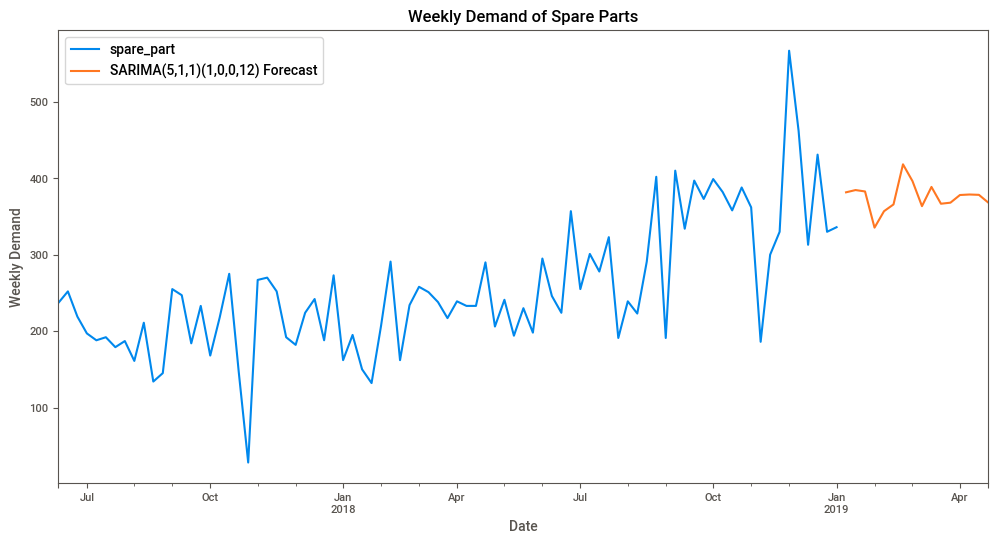

In [101]:
title = 'Weekly Demand of Spare Parts'
ylabel='Weekly Demand'
xlabel='Date'

ax = weekly_data_indexed['spare_part'].plot(legend=True,figsize=(12,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)